In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import your actual data loader and constants
from cooltrack.data_loader import load_grid
from cooltrack.constants import INDEPENDENT_DIMS, SECONDS_PER_YR

# Setup Plotting
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12

In [2]:
# Assume load_grid is imported or defined in your notebook
# from some_module import load_grid 

# =====================================================================
# 1. LOAD THE RAW GRID (Using your exact ExoWeave loader)
# =====================================================================
GRID_PATH = "../../exoweave/outputs/master_grid_cooltrack.h5" 

print("Loading full unstructured grid...")
df = load_grid(GRID_PATH, use_cache=False)

# Ensure standard column naming
if 'dsdt' not in df.columns and 'dsdt_J_K_kg_s' in df.columns:
    df['dsdt'] = df['dsdt_J_K_kg_s']

# Filter valid cooling states
df = df[(df['T_int'] > 0) & (df['dsdt'] < 0)].copy()

# Compute required logarithmic physics variables
df['ln_Tint'] = np.log(df['T_int'])
df['ln_tau'] = -np.log(np.abs(df['dsdt']))

# Drop any NaNs that might mess up the regression
clean_cols = INDEPENDENT_DIMS + ['ln_Tint', 'S_physical', 'ln_tau']
df = df.dropna(subset=clean_cols).reset_index(drop=True)

print(f"Prepared {len(df)} total physical states.")



2026-05-04 16:14:14,482 - INFO - ⏳ Parquet cache not found or disabled. Running parallel HDF5 extraction...
2026-05-04 16:14:14,483 - INFO - Loading Exoweave HDF5 file: ../../exoweave/outputs/master_grid_cooltrack.h5...


Loading full unstructured grid...


2026-05-04 16:14:15,335 - INFO - Spinning up 47 workers to read HDF5 across network...
Reading HDF5 Chunks: 100%|██████████| 190/190 [00:18<00:00, 10.10it/s]


Extracted 21378 models from Exoweave HDF5 file.


2026-05-04 16:14:46,902 - INFO - ✅ Exoweave Grid loaded and mapped successfully. Final shape: (20999, 301)


Prepared 20999 total physical states.


In [3]:
# =====================================================================
# 2. INITIALIZE THE COOLTRACK ENGINE
# =====================================================================
from cooltrack.initial_conditions import InitialConditions
from cooltrack.cooltrack import SemiAnalyticalCoolTrack

# Point this to your actual initial conditions folder
IC_PATH = "../data/age_data" 

print("\nInitializing Theoretical Boundary Conditions...")
init_conds = InitialConditions(age_data_path=IC_PATH)

print("Spinning up Semi-Analytical Engine...")
engine = SemiAnalyticalCoolTrack(df, init_conds, INDEPENDENT_DIMS, bandwidth=0.5)

# =====================================================================
# 3. DEFINE TARGET & EVOLVE!
# =====================================================================
target = {
    'mass_Mj': 1.0, 
    'T_irr': 100.0, 
    'Met': 0.0, 
    'core': 10.0, 
    'f_sed_refractory': 3.0,  # <-- Need both now!
    'f_sed_volatile': 6.0,    # <-- Need both now! 
    'kzz': 8.0
}

bands_to_track = [
    'log_JWST/MIRI.F1130W', 
    'log_Paranal/SPHERE.IRDIS_B_H', 
    'log_Keck/NIRC2.J'
]

print(f"\nFitting surrogate models for M = {target['mass_Mj']} Mjup...")
fits = engine.fit_surrogate(target, photometry_bands=bands_to_track)

print("Integrating Hot Start Evolution...")
hot_track = engine.evolve(fits, start_type=19)

print("Integrating Cold Start Evolution...")
cold_track = engine.evolve(fits, start_type=1)

print("\n✅ Success! --- Hot Start Track (First 5 Rows) ---")
print(hot_track[['age_yr', 'T_int', 'Req_Rj'] + bands_to_track].head())

2026-05-04 16:14:47,964 - INFO - Loaded initial condition interpolators from 4 files.



Initializing Theoretical Boundary Conditions...
Spinning up Semi-Analytical Engine...

Fitting surrogate models for M = 1.0 Mjup...
Radius fit successful with R²=0.962
Radius fit parameters: [11.2169567   0.53828017 -0.5         6.12898543  5.        ]
Integrating Hot Start Evolution...
Integrating Cold Start Evolution...

✅ Success! --- Hot Start Track (First 5 Rows) ---
         age_yr        T_int    Req_Rj  log_JWST/MIRI.F1130W  \
0      0.000000  1347.598633  2.113618              2.974738   
1   5722.816454  1339.007137  2.106039              2.969273   
2  11616.052976  1330.470416  2.098506              2.963872   
3  17684.780507  1321.988120  2.091019              2.958532   
4  23934.220490  1313.559902  2.083578              2.953254   

   log_Paranal/SPHERE.IRDIS_B_H  log_Keck/NIRC2.J  
0                      4.849101          4.970555  
1                      4.842377          4.951412  
2                      4.835593          4.932593  
3                      4.828748

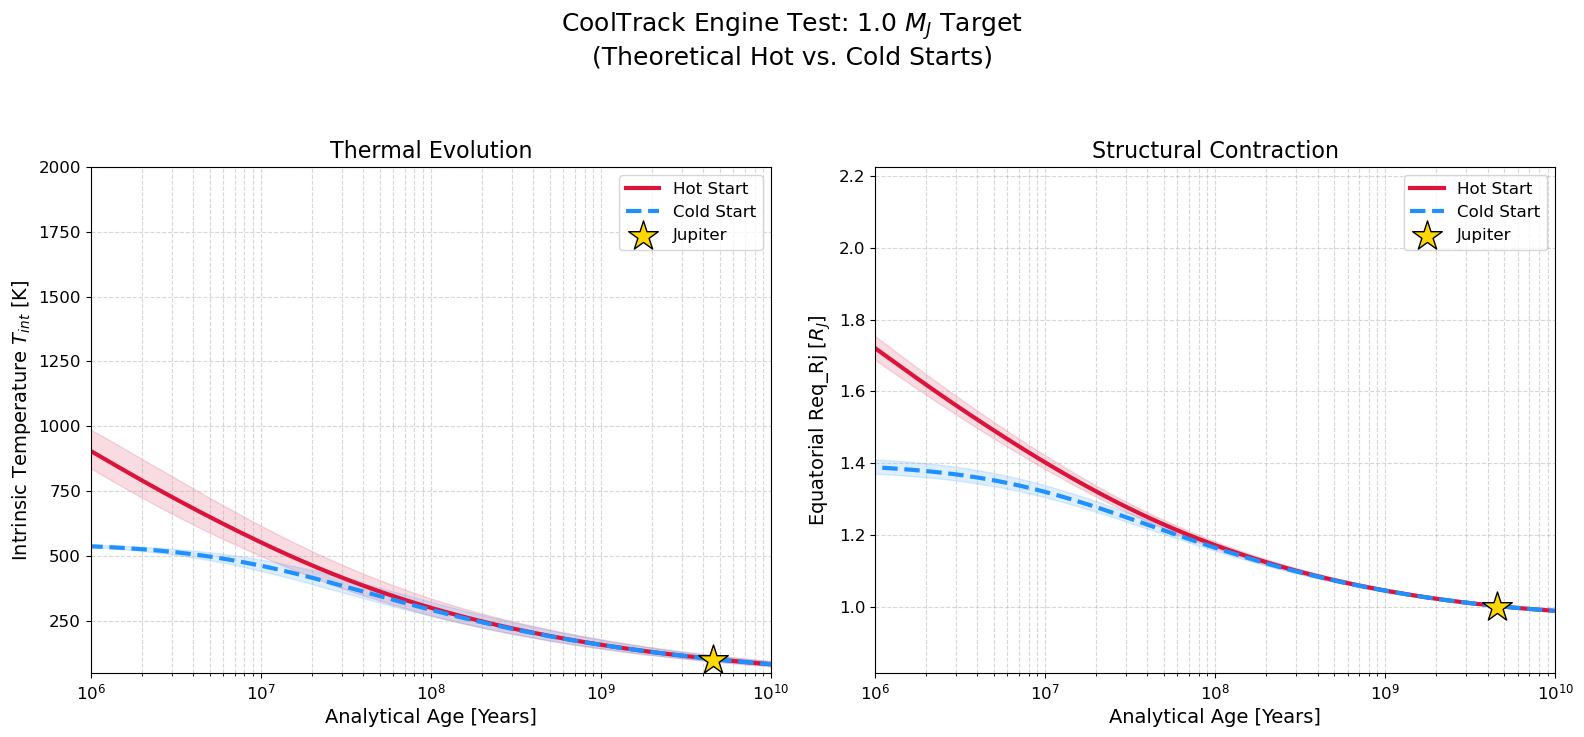

In [4]:
# =====================================================================
# 4. VISUALIZE THE RESULTS (The "Tuning Fork" Plot)
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Panel 1: Thermal Evolution ---
# Hot Start (Red)
ax1.plot(hot_track['age_yr'], hot_track['T_int'], color='crimson', lw=3, label='Hot Start')
ax1.fill_betweenx(hot_track['T_int'], hot_track['age_yr_lower'], hot_track['age_yr_upper'], color='crimson', alpha=0.15)

# Cold Start (Blue)
ax1.plot(cold_track['age_yr'], cold_track['T_int'], color='dodgerblue', lw=3, label='Cold Start', linestyle='--')
ax1.fill_betweenx(cold_track['T_int'], cold_track['age_yr_lower'], cold_track['age_yr_upper'], color='dodgerblue', alpha=0.15)

ax1.scatter(4.56e9, 99.0, color='gold', edgecolor='black', marker='*', s=500, zorder=10, label='Jupiter')

ax1.set_xscale('log')
ax1.set_xlim(1e6, 1e10)
ax1.set_ylim(50, 2000)
ax1.set_xlabel('Analytical Age [Years]', fontsize=14)
ax1.set_ylabel('Intrinsic Temperature $T_{int}$ [K]', fontsize=14)
ax1.set_title('Thermal Evolution', fontsize=16)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend(fontsize=12)

# --- Panel 2: Structural Evolution ---
# Hot Start (Red)
ax2.plot(hot_track['age_yr'], hot_track['Req_Rj'], color='crimson', lw=3, label='Hot Start')
ax2.fill_between(hot_track['age_yr'], hot_track['Req_Rj_lower'], hot_track['Req_Rj_upper'], color='crimson', alpha=0.15)

# Cold Start (Blue)
ax2.plot(cold_track['age_yr'], cold_track['Req_Rj'], color='dodgerblue', lw=3, label='Cold Start', linestyle='--')
ax2.fill_between(cold_track['age_yr'], cold_track['Req_Rj_lower'], cold_track['Req_Rj_upper'], color='dodgerblue', alpha=0.15)

ax2.scatter(4.56e9, 1.0, color='gold', edgecolor='black', marker='*', s=500, zorder=10, label='Jupiter')

ax2.set_xscale('log')
ax2.set_xlim(1e6, 1e10)
bottom, top = ax2.get_ylim()
ax2.set_ylim(max(0.5, bottom - 0.1), top) 
ax2.set_xlabel('Analytical Age [Years]', fontsize=14)
ax2.set_ylabel('Equatorial Req_Rj [$R_J$]', fontsize=14)
ax2.set_title('Structural Contraction', fontsize=16)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend(fontsize=12)

# Master Title
fig.suptitle(f'CoolTrack Engine Test: {target["mass_Mj"]} $M_J$ Target\n(Theoretical Hot vs. Cold Starts)', fontsize=18, y=1.05)

plt.tight_layout()
plt.show()

Processing T_irr = 100.0 K...
Radius fit successful with R²=0.965
Radius fit parameters: [11.21950317  0.54160589 -0.5         6.08069496  5.        ]


Processing T_irr = 500.0 K...
Radius fit successful with R²=0.963
Radius fit parameters: [11.1902103   0.46404242 -0.5         5.60053057  5.        ]
Processing T_irr = 1000.0 K...
Radius fit successful with R²=0.969
Radius fit parameters: [11.21761098  0.55177822 -0.5         6.30018945  5.        ]


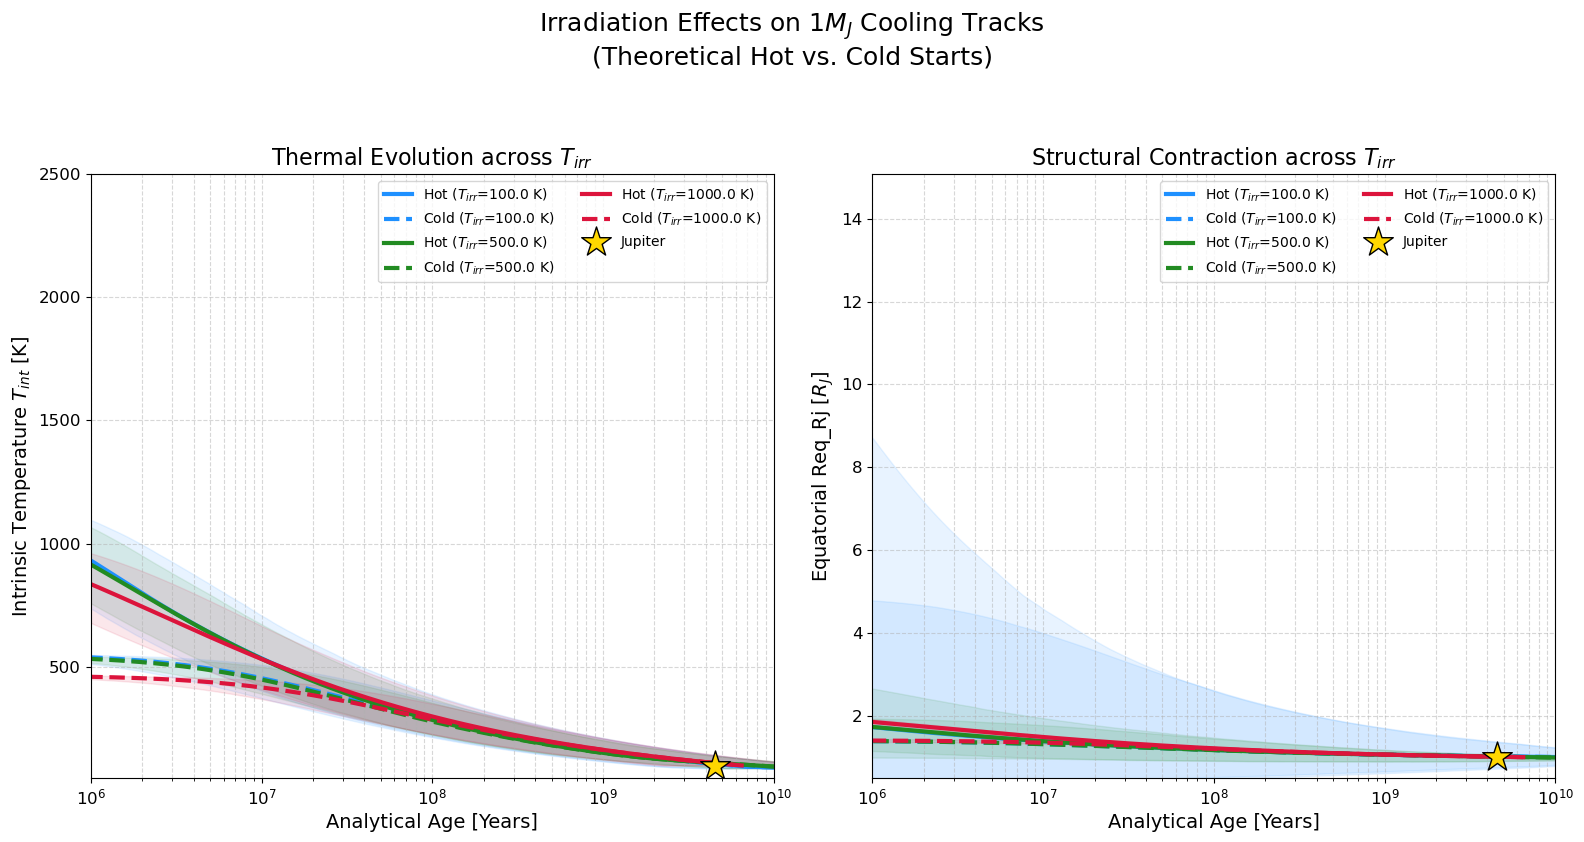

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the irradiation temperatures you want to compare
t_irr_list = [100.0, 500.0, 1000.0]

# Define a distinct color for each T_irr (e.g., Blue for 100K, Green for 500K, Red for 1000K)
colors = ['dodgerblue', 'forestgreen', 'crimson']

# Create the Two-Panel Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Define the base target planet (mass, met, core, etc.)
target = {
    'mass_Mj': 1.0, 
    'Met': 0.0, 
    'core': 10.0, 
    'f_sed_refractory': 3.0,  # <-- Need both now!
    'f_sed_volatile': 3.0,    # <-- Need both now! 
    'kzz': 8.0
}

# 2. Loop over the irradiation temperatures
for idx, t_irr in enumerate(t_irr_list):
    color = colors[idx]
    
    # Update the target dictionary with the current T_irr
    target['T_irr'] = t_irr
    
    print(f"Processing T_irr = {t_irr} K...")
    
    # Run the engine for this specific configuration
    fits = engine.fit_surrogate(target)
    hot_track = engine.evolve(fits, start_type=19)
    cold_track = engine.evolve(fits, start_type=1)
    
    # =========================================================
    # THE FIX: Drop the t=0 singularity to prevent log-scale crashes
    # =========================================================
    hot_plot = hot_track[hot_track['age_yr'] > 0].copy()
    cold_plot = cold_track[cold_track['age_yr'] > 0].copy()
    
    # ==========================================
    # PANEL 1: Thermal Evolution (Age vs T_int)
    # ==========================================
    # Hot Start (Solid Line)
    ax1.plot(hot_plot['age_yr'], hot_plot['T_int'], color=color, lw=3, 
             label=f'Hot ($T_{{irr}}$={t_irr} K)')
    ax1.fill_betweenx(hot_plot['T_int'], hot_plot['age_yr_lower'], hot_plot['age_yr_upper'], 
                      color=color, alpha=0.1)
    
    # Cold Start (Dashed Line)
    ax1.plot(cold_plot['age_yr'], cold_plot['T_int'], color=color, lw=3, linestyle='--', 
             label=f'Cold ($T_{{irr}}$={t_irr} K)')
    ax1.fill_betweenx(cold_plot['T_int'], cold_plot['age_yr_lower'], cold_plot['age_yr_upper'], 
                      color=color, alpha=0.1)

    # ==========================================
    # PANEL 2: Structural Evolution (Age vs Req_Rj)
    # ==========================================
    # Hot Start (Solid Line)
    ax2.plot(hot_plot['age_yr'], hot_plot['Req_Rj'], color=color, lw=3, 
             label=f'Hot ($T_{{irr}}$={t_irr} K)')
    ax2.fill_between(hot_plot['age_yr'], hot_plot['Req_Rj_lower'], hot_plot['Req_Rj_upper'], 
                     color=color, alpha=0.1)
    
    # Cold Start (Dashed Line)
    ax2.plot(cold_plot['age_yr'], cold_plot['Req_Rj'], color=color, lw=3, linestyle='--', 
             label=f'Cold ($T_{{irr}}$={t_irr} K)')
    ax2.fill_between(cold_plot['age_yr'], cold_plot['Req_Rj_lower'], cold_plot['Req_Rj_upper'], 
                     color=color, alpha=0.1)

# 3. Add Jupiter Benchmark
ax1.scatter(4.56e9, 99.0, color='gold', edgecolor='black', marker='*', s=500, zorder=10, label='Jupiter')
ax2.scatter(4.56e9, 1.0, color='gold', edgecolor='black', marker='*', s=500, zorder=10, label='Jupiter')

# 4. Format the final plots
# --- Thermal Panel ---
ax1.set_xscale('log')
ax1.set_xlim(1e6, 1e10)
ax1.set_ylim(50, 2500)
ax1.set_xlabel('Analytical Age [Years]', fontsize=14)
ax1.set_ylabel('Intrinsic Temperature $T_{int}$ [K]', fontsize=14)
ax1.set_title('Thermal Evolution across $T_{irr}$', fontsize=16)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend(fontsize=10, ncol=2, loc='upper right')

# --- Req_Rj Panel ---
ax2.set_xscale('log')
ax2.set_xlim(1e6, 1e10)
# Dynamic Y-limits based on how puffed up the 1000K planet gets
bottom, top = ax2.get_ylim()
ax2.set_ylim(max(0.5, bottom - 0.1), top + 0.1) 
ax2.set_xlabel('Analytical Age [Years]', fontsize=14)
ax2.set_ylabel('Equatorial Req_Rj [$R_J$]', fontsize=14)
ax2.set_title('Structural Contraction across $T_{irr}$', fontsize=16)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend(fontsize=10, ncol=2, loc='upper right')

# Master Title
fig.suptitle(f'Irradiation Effects on $1 M_J$ Cooling Tracks\n(Theoretical Hot vs. Cold Starts)', fontsize=18, y=1.05)

plt.tight_layout()
plt.show()

Processing Mass = 1.0 M_J...


Radius fit successful with R²=0.962
Radius fit parameters: [11.2169567   0.53828017 -0.5         6.12898543  5.        ]
Processing Mass = 5.0 M_J...
Radius fit successful with R²=0.976
Radius fit parameters: [11.4236134   1.07849053 -0.21121819  8.9461106   5.        ]
Processing Mass = 10.0 M_J...
Radius fit successful with R²=0.968
Radius fit parameters: [11.43940017  1.07739456 -0.19444194  8.98359676  5.        ]


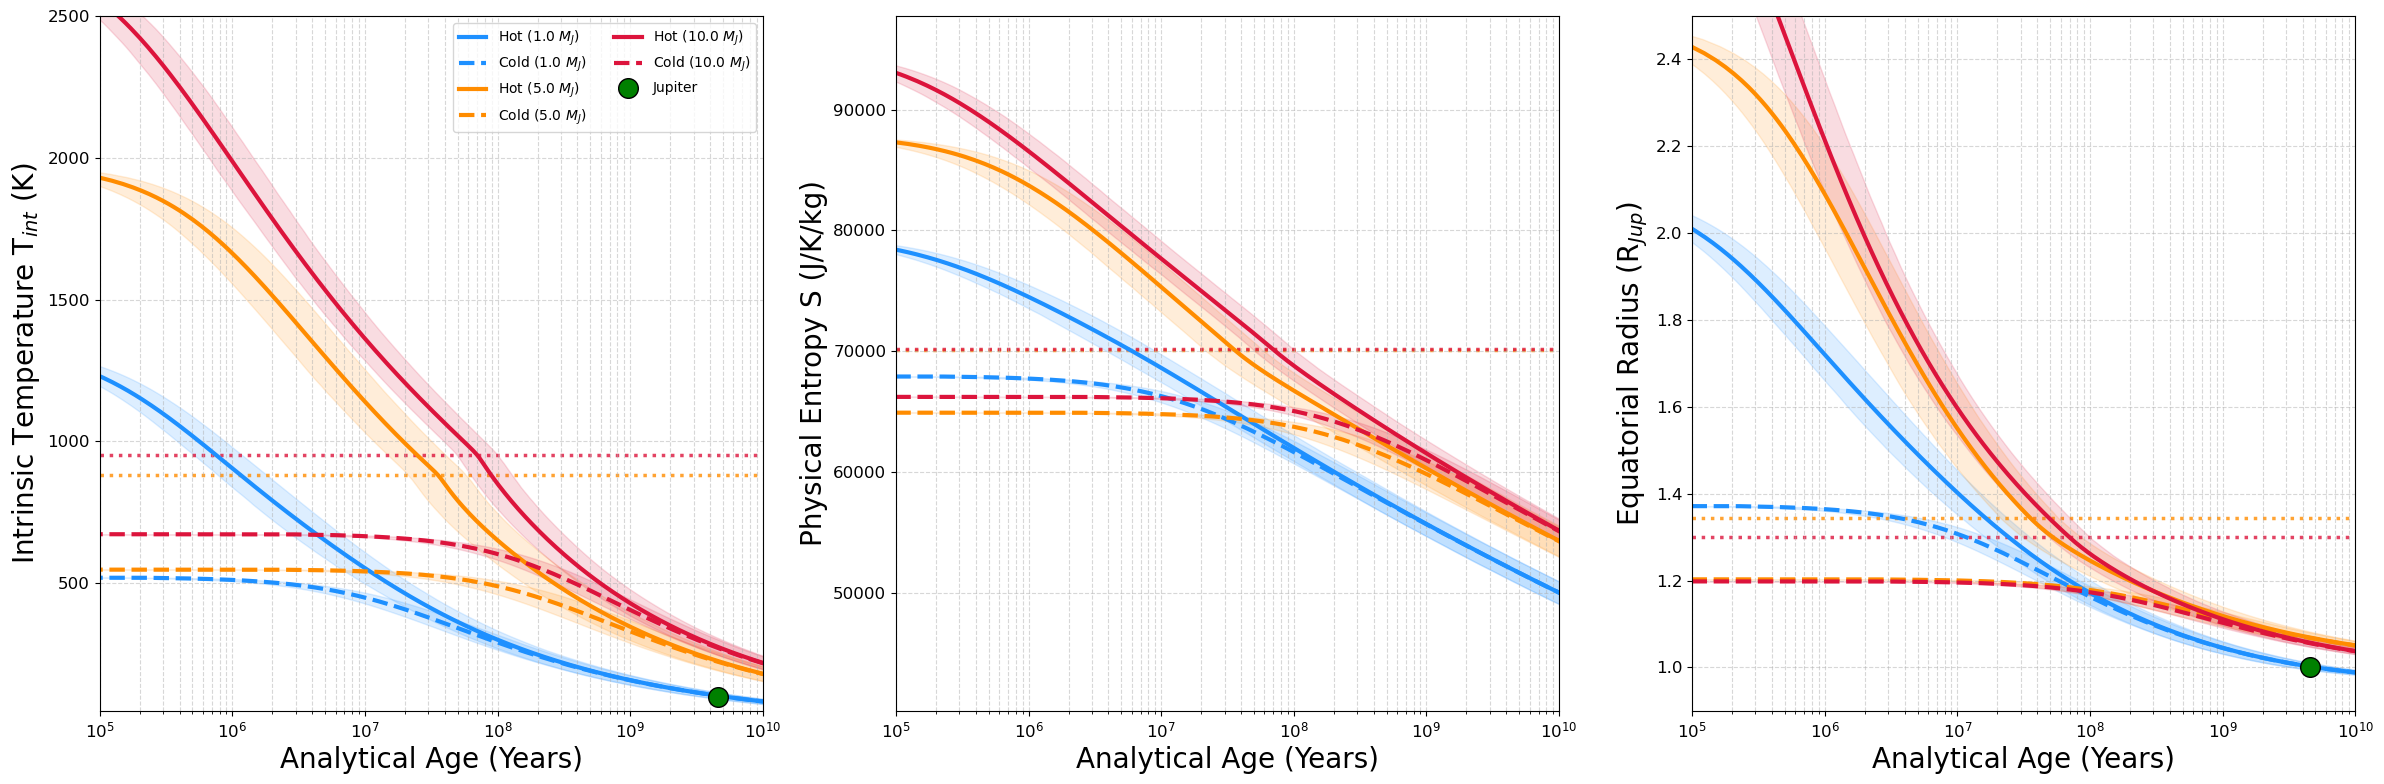

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from cooltrack.cooltrack import softplus_piecewise, dual_softplus_piecewise

# 1. Define the planetary masses you want to compare
mass_list = [1.0, 5.0, 10.0]
colors = ['dodgerblue', 'darkorange', 'crimson']

# Create a Three-Panel Figure to trace the physics
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

target = {
    'T_irr': 100.0, 
    'Met': 0.0, 
    'core': 10.0, 
    'f_sed_refractory': 3.0,  
    'f_sed_volatile': 6.0,    
    'kzz': 8.0
}

# 2. Loop over the planetary masses
for idx, mass in enumerate(mass_list):
    color = colors[idx]
    
    target['mass_Mj'] = mass
    print(f"Processing Mass = {mass} M_J...")
    
    # Run the engine
    fits = engine.fit_surrogate(target)
    hot_track = engine.evolve(fits, start_type=19) # 19 = Hot Start limit
    cold_track = engine.evolve(fits, start_type=0) # 0 = Cold Start limit
    
    # ==========================================
    # --- Extract and Plot Knees (Horizontal) ---
    # ==========================================
    t_knee = None
    ln_t_knee = None
    
    # 1. Evaluate the Primary Temperature Knee
    if fits.get('method_S') == 'dual_softplus':
        ln_knee_1 = fits['popt_S'][1]
        ln_knee_2 = fits['popt_S'][5]
        
        # --- THE FIX: Use Peak Curvature to define "Abruptness" ---
        # Curvature is proportional to: |change in slope| * sharpness (beta)
        k1, k2, beta1 = fits['popt_S'][2], fits['popt_S'][3], fits['popt_S'][4]
        k3, beta2 = fits['popt_S'][6], fits['popt_S'][7]
        
        t1 = np.exp(ln_knee_1)
        t2 = np.exp(ln_knee_2)
        
        abruptness_1 = abs(k2 - k1) * beta1
        abruptness_2 = abs(k3 - k2) * beta2
        
        # Filter for validity (> 200 K) before comparing
        valid_knees = []
        if t1 > 200.0:
            valid_knees.append((t1, ln_knee_1, abruptness_1))
        if t2 > 200.0:
            valid_knees.append((t2, ln_knee_2, abruptness_2))
            
        if len(valid_knees) == 2:
            # Both are above 200K: Pick the one with the highest curvature (most dramatic)
            best_knee = max(valid_knees, key=lambda item: item[2])
            t_knee, ln_t_knee, _ = best_knee
        elif len(valid_knees) == 1:
            # Only one is above 200K
            t_knee, ln_t_knee, _ = valid_knees[0]
            
    elif fits.get('method_S') == 'softplus':
        ln_k = fits['popt_S'][0]
        t_k = np.exp(ln_k)
        if t_k > 200.0:
            t_knee = t_k
            ln_t_knee = ln_k
            
    # Only plot if we successfully found a valid knee
    if t_knee is not None:
        # Plot T_int threshold on Panel 1
        ax1.axhline(t_knee, color=color, ls=':', lw=2.5, alpha=0.8, zorder=1)
        
        # --- Map T_int -> S -> Req through the surrogates ---
        # A. Map Temperature to Entropy
        if fits.get('method_S') == 'dual_softplus':
            ln_s_knee = dual_softplus_piecewise(ln_t_knee, *fits['popt_S'])
        elif fits.get('method_S') == 'softplus':
            ln_s_knee = softplus_piecewise(ln_t_knee, *fits['popt_S'])
        else:
            ln_s_knee = fits['C'] * ln_t_knee + fits['D']
            
        # Plot S threshold on Panel 2
        ax2.axhline(np.exp(ln_s_knee), color=color, ls=':', lw=2.5, alpha=0.8, zorder=1)
        
        # B. Map Entropy to Radius
        if 'popt_R' in fits:
            r_knee = np.exp(softplus_piecewise(ln_s_knee, *fits['popt_R']))
            # Plot Req threshold on Panel 3
            ax3.axhline(r_knee, color=color, ls=':', lw=2.5, alpha=0.8, zorder=1)

    # ==========================================
    # --- Enforce Monotonic Time ---
    # ==========================================
    for col in ['age_yr', 'age_yr_lower', 'age_yr_upper']:
        hot_track.loc[hot_track[col] <= 0, col] = 1.0
        cold_track.loc[cold_track[col] <= 0, col] = 1.0
        hot_track[col] = np.maximum.accumulate(hot_track[col])
        cold_track[col] = np.maximum.accumulate(cold_track[col])

    # ==========================================
    # PANEL 1: Thermal Evolution (Age vs T_int)
    # ==========================================
    ax1.plot(hot_track['age_yr'], hot_track['T_int'], color=color, lw=3, label=f'Hot ({mass} $M_J$)')
    ax1.fill_betweenx(hot_track['T_int'], hot_track['age_yr_lower'], hot_track['age_yr_upper'], color=color, alpha=0.15)
    
    ax1.plot(cold_track['age_yr'], cold_track['T_int'], color=color, lw=3, linestyle='--', label=f'Cold ({mass} $M_J$)')
    ax1.fill_betweenx(cold_track['T_int'], cold_track['age_yr_lower'], cold_track['age_yr_upper'], color=color, alpha=0.15)

    # ==========================================
    # PANEL 2: Thermodynamic Evolution (Age vs Entropy)
    # ==========================================
    ax2.plot(hot_track['age_yr'], hot_track['S_physical'], color=color, lw=3, label=f'Hot ({mass} $M_J$)')
    ax2.fill_betweenx(hot_track['S_physical'], hot_track['age_yr_lower'], hot_track['age_yr_upper'], color=color, alpha=0.15)
    
    ax2.plot(cold_track['age_yr'], cold_track['S_physical'], color=color, lw=3, linestyle='--', label=f'Cold ({mass} $M_J$)')
    ax2.fill_betweenx(cold_track['S_physical'], cold_track['age_yr_lower'], cold_track['age_yr_upper'], color=color, alpha=0.15)

    # ==========================================
    # PANEL 3: Structural Evolution (Age vs Req_Rj)
    # ==========================================
    ax3.plot(hot_track['age_yr'], hot_track['Req_Rj'], color=color, lw=3, label=f'Hot ({mass} $M_J$)')
    ax3.fill_betweenx(hot_track['Req_Rj'], hot_track['age_yr_lower'], hot_track['age_yr_upper'], color=color, alpha=0.15)
    
    ax3.plot(cold_track['age_yr'], cold_track['Req_Rj'], color=color, lw=3, linestyle='--', label=f'Cold ({mass} $M_J$)')
    ax3.fill_betweenx(cold_track['Req_Rj'], cold_track['age_yr_lower'], cold_track['age_yr_upper'], color=color, alpha=0.15)

# 3. Add Jupiter Benchmark
ax1.scatter(4.56e9, 99.0, color='green', edgecolor='black', marker='o', s=200, zorder=10, label='Jupiter')
ax3.scatter(4.56e9, 1.0, color='green', edgecolor='black', marker='o', s=200, zorder=10, label='Jupiter')

# 4. Format the final plots
ax1.set_xscale('log')
ax1.set_xlim(1e5, 1e10)
ax1.set_ylim(50, 2500)
ax1.set_xlabel(r'Analytical Age (Years)', fontsize=20)
ax1.set_ylabel(r'Intrinsic Temperature T$_{int}$ (K)', fontsize=20)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend(fontsize=10, ncol=2, loc='upper right')

ax2.set_xscale('log')
ax2.set_xlim(1e5, 1e10)
ax2.set_xlabel(r'Analytical Age (Years)', fontsize=20)
ax2.set_ylabel(r'Physical Entropy S (J/K/kg)', fontsize=20)
ax2.grid(True, which="both", ls="--", alpha=0.5)

ax3.set_xscale('log')
ax3.set_xlim(1e5, 1e10) 
ax3.set_ylim(0.9, 2.5) 
ax3.set_xlabel(r'Analytical Age (Years)', fontsize=20)
ax3.set_ylabel(r'Equatorial Radius (R$_{Jup}$)', fontsize=20)
ax3.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.savefig('../figures/evolution_mass_starts_3panel.pdf', dpi=300, bbox_inches='tight')
plt.show()

Generating unscaled surface flux lightcurves...
Radius fit successful with R²=0.965
Radius fit parameters: [11.21950317  0.54160589 -0.5         6.08069496  5.        ]


Radius fit successful with R²=0.978
Radius fit parameters: [11.44309878  1.19181374 -0.22421128  9.74698787  5.        ]
Radius fit successful with R²=0.968
Radius fit parameters: [11.41373017  0.94934467 -0.18707859  7.91112755  5.        ]


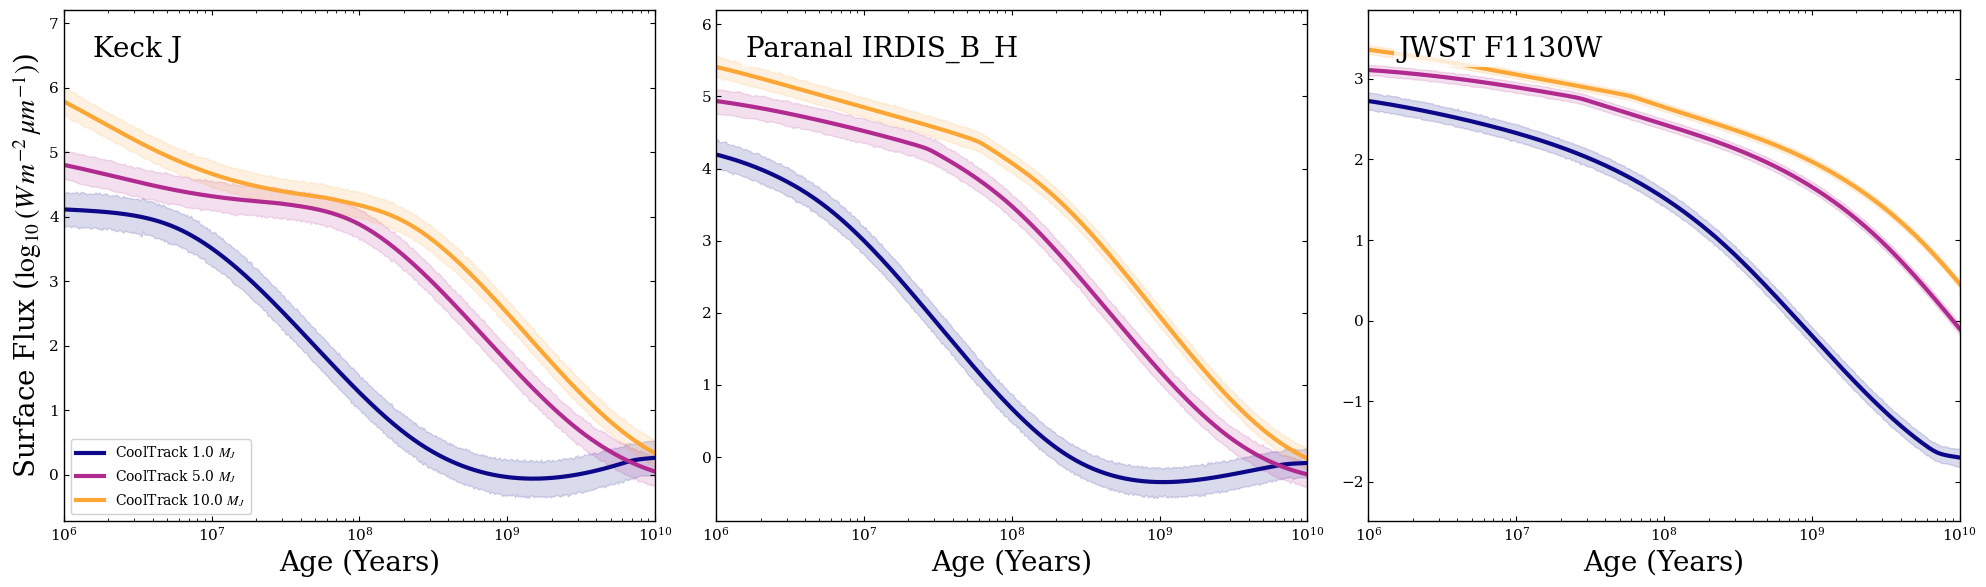

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- A&A Publication Formatting ---
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix', 
    'font.size': 11,
    'axes.labelsize': 20,
    'legend.fontsize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
})

# =====================================================================
# 1. CONFIGURATION
# =====================================================================
masses_to_test = [1.0, 5.0, 10.0] 
bands_to_track = [
    'log_Keck/NIRC2.J', 
    'log_Paranal/SPHERE.IRDIS_B_H',
    'log_JWST/MIRI.F1130W',
]

# We will use the plasma colormap to keep consistency with your previous figures
colors = plt.cm.plasma(np.linspace(0, 0.8, len(masses_to_test)))

# Create a 1x3 Figure for the three bands
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('white') 

print("Generating unscaled surface flux lightcurves...")

# =====================================================================
# 2. RUN THE ENGINE & PLOT
# =====================================================================
for idx, mass in enumerate(masses_to_test):
    # Base planet configuration
    target_planet = {'mass_Mj': mass, 
    'T_irr': 100.0, 
    'Met': 0.0, 
    'core': 10.0, 
    'f_sed_refractory': 3.0,  # <-- Need both now!
    'f_sed_volatile': 3.0,    # <-- Need both now! 
    'kzz': 8.0}
    
    # Fit engine and evolve (MAKE SURE TO ADD photometry_method!)
    fits = engine.fit_surrogate(
        target_planet, 
        photometry_bands=bands_to_track,
        photometry_method='bspline'   # <--- ADD THIS LINE
    )
    track_df = engine.evolve(fits, start_type=15, n_points=500)
    
    # Drop the t=0 singularity to prevent log-scale geometry crashes
    plot_df = track_df[track_df['age_yr'] > 0].copy()
    
    # Plot the results in their respective subplots
    for ax_idx, band in enumerate(bands_to_track):
        ax = axes[ax_idx]
        
        # Plot Median Track
        ax.plot(plot_df['age_yr'], plot_df[band], 
                color=colors[idx], linewidth=3, label=f'CoolTrack {mass} $M_J$')
        
        # Add the 1-sigma uncertainty envelope (shaded region)
        lower_col = f"{band}_lower"
        upper_col = f"{band}_upper"
        
        if lower_col in plot_df.columns and upper_col in plot_df.columns:
            ax.fill_between(plot_df['age_yr'], plot_df[lower_col], plot_df[upper_col], 
                            color=colors[idx], alpha=0.15)

# =====================================================================
# 3. FORMAT PLOTS 
# =====================================================================
for ax_idx, band in enumerate(bands_to_track):
    ax = axes[ax_idx]
    
    # Extract clean names for the annotations (e.g., gets 'F1130W' out of the long string)
    band_name = band.split('.')[-1]
    observatory = band.split('/')[0].replace('log_', '')
    
    # Standard formatting
    ax.set_xscale('log')
    ax.set_xlim(1e6, 1e10)
    ax.set_xlabel(r'Age (Years)')
    
    # Only label the Y-axis on the leftmost plot to keep things clean
    if ax_idx == 0:
        ax.set_ylabel(r'Surface Flux ($\log_{10}(W\,m^{-2}\,\mu m^{-1})$)')
        
    # --- A&A FORMATTING FIXES ---
    ax.set_facecolor('white')  
    ax.grid(False) # Removed background grid lines
    
    # Move the title INSIDE the plot area since A&A doesn't use subplot titles
    label_text = f'{observatory} {band_name}'
    ax.text(0.05, 0.95, label_text, transform=ax.transAxes, fontsize=20, 
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))
    
    # Enforce solid black bounding boxes
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.0)
    
    # Only show the legend on the first plot to avoid redundancy
    if ax_idx == 0:
        ax.legend(loc='lower left', framealpha=0.9)

plt.tight_layout()
plt.savefig('../figures/surface_flux_lightcurves.pdf', dpi=300, bbox_inches='tight')
plt.show()

Radius fit successful with R²=0.972
Radius fit parameters: [11.35332697  0.7184237  -0.16717572  6.28647702  5.        ]


/tmp/ipykernel_319458/4042919019.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper right', framealpha=0.9)
/tmp/ipykernel_319458/4042919019.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper right', framealpha=0.9)


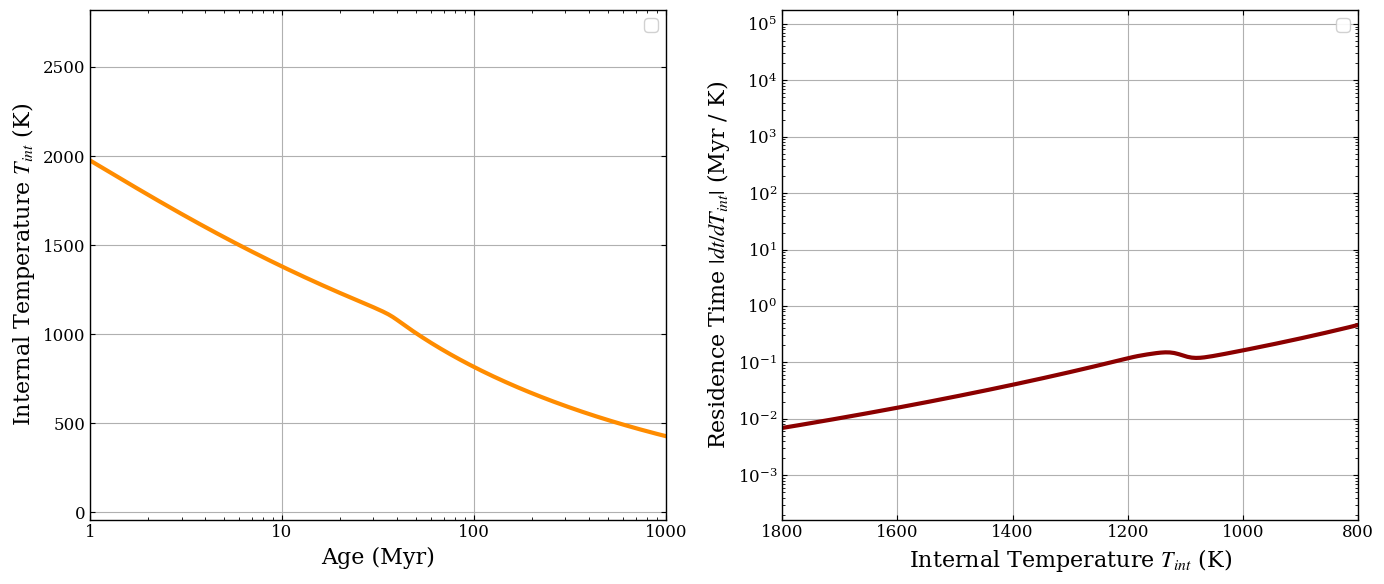

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# --- A&A Publication Formatting ---
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix', 
    'font.size': 12,
    'axes.labelsize': 16,
    'legend.fontsize': 12,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
})

# 1. Base planet configuration (10 M_Jup as your co-author requested)
target_planet = {
    'mass_Mj': 10.0, 
    'T_irr': 100.0, 
    'Met': 0.0, 
    'core': 10.0, 
    'f_sed_refractory': 1.0,  
    'f_sed_volatile': 1.0,    
    'kzz': 8.0
}

# 2. Extract fits and evolve
fits = engine.fit_surrogate(target_planet)
track_df = engine.evolve(fits, start_type=19, n_points=500)
plot_df = track_df[track_df['age_yr'] > 0].copy()

# 3. Calculate the Derivatives (The core of your co-author's request)
# Convert age to Millions of Years for cleaner axes
age_myr = plot_df['age_yr'].values / 1e6
t_int = plot_df['T_int'].values

# Use np.gradient to compute derivatives while keeping array lengths consistent
dt_myr = np.gradient(age_myr)
dT_int = np.gradient(t_int)

# Residence Time: How many Millions of Years does the planet spend per Kelvin?
residence_time = np.abs(dt_myr / dT_int)

# =====================================================================
# 4. PLOTTING ROUTINE
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

# --- Panel 1: The Cooling Curve ---
ax1.plot(age_myr, t_int, color='darkorange', lw=3)
ax1.set_xscale('log')
ax1.set_xlim(1, 1000) # Zoom in on the 1 to 1000 Myr window
ax1.set_xlabel('Age (Myr)')
ax1.set_ylabel(r'Internal Temperature $T_{int}$ (K)')

# Highlight the L/T Transition Zone
#ax1.axhspan(1200, 1400, color='gray', alpha=0.15, label='L/T Transition Zone')

# Format log axis so it shows 10, 100 instead of 10^1, 10^2
formatter = ScalarFormatter()
formatter.set_scientific(False)
ax1.xaxis.set_major_formatter(formatter)
ax1.legend(loc='upper right', framealpha=0.9)

# --- Panel 2: The Pile-Up (Residence Time Derivative) ---
ax2.plot(t_int, residence_time, color='darkred', lw=3)
ax2.set_xlabel(r'Internal Temperature $T_{int}$ (K)')
ax2.set_ylabel(r'Residence Time $|dt / dT_{int}|$ (Myr / K)')

# Highlight the L/T Transition Zone
#ax2.axvspan(1200, 1400, color='gray', alpha=0.15, label='L/T Transition Zone')

# Invert X-axis so it reads hot-to-cold (left-to-right), mimicking time progression
ax2.invert_xaxis()
ax2.set_xlim(1800, 800) 
ax2.set_yscale('log')  # Log scale to better visualize the spike
ax2.legend(loc='upper right', framealpha=0.9)

# Add a text annotation pointing to the spike
spike_idx = np.argmax(residence_time)
ax2.annotate('Cooling\nSlowdown Pile-up', 
             xy=(t_int[spike_idx], residence_time[spike_idx]), 
             xytext=(t_int[spike_idx] - 150, residence_time[spike_idx] * 0.8),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=12, fontweight='bold', ha='center')

# Bounding boxes
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig('../figures/lt_transition_pileup.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
residence_time

array([4.21074950e-04, 4.31404790e-04, 4.52644049e-04, 4.74928976e-04,
       4.98311052e-04, 5.22844292e-04, 5.48585372e-04, 5.75593757e-04,
       6.03931840e-04, 6.33665085e-04, 6.64862182e-04, 6.97595198e-04,
       7.31939751e-04, 7.67975183e-04, 8.05784739e-04, 8.45455765e-04,
       8.87079906e-04, 9.30753319e-04, 9.76576896e-04, 1.02465649e-03,
       1.07510319e-03, 1.12803351e-03, 1.18356974e-03, 1.24184017e-03,
       1.30297942e-03, 1.36712873e-03, 1.43443628e-03, 1.50505757e-03,
       1.57915574e-03, 1.65690198e-03, 1.73847587e-03, 1.82406588e-03,
       1.91386972e-03, 2.00809486e-03, 2.10695896e-03, 2.21069041e-03,
       2.31952885e-03, 2.43372572e-03, 2.55354481e-03, 2.67926293e-03,
       2.81117050e-03, 2.94957225e-03, 3.09478790e-03, 3.24715293e-03,
       3.40701930e-03, 3.57475635e-03, 3.75075156e-03, 3.93541150e-03,
       4.12916276e-03, 4.33245294e-03, 4.54575166e-03, 4.76955166e-03,
       5.00436997e-03, 5.25074904e-03, 5.50925803e-03, 5.78049414e-03,
      